# Module 7 Challenge - Object Detection Model Deployment
This model revolves around deploying a previous project, specifically the handheld device detection model, using Flask and Docker. The goal of this project is to deploy the model to make it accessible online with a functional user-friendly interface.
The model of interest is an object detection model which was previously built, trained and evaluated based on its classification between 2 devices, a Nintendo Switch and a Steam Deck. The reason I chose this project to deploy is because I find this project to be extremely interesting and I am curious and eager to deploy a CV project.

## Loading Model and Preparing for Deployment
In this section, we will install the necessary libraries to load the model and prepare it for deployment to the Flask app.

### Installing Packages and Importing Libraries

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive

drive.mount('/content/drive')

model = YOLO("/content/drive/MyDrive/Object_Detection_Deployment/best.pt")

print("Model loaded successfully!")

Mounted at /content/drive
Model loaded successfully!


In [4]:
print("Classes:", model.names)

Classes: {0: 'nintendo switch', 1: 'steam deck'}


In [5]:
from google.colab import files

uploaded = files.upload()

Saving nintendo.jpeg to nintendo.jpeg


In [6]:
image_path = next(iter(uploaded))

results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)


image 1/1 /content/nintendo.jpeg: 384x640 1 nintendo switch, 79.3ms
Speed: 12.5ms preprocess, 79.3ms inference, 40.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


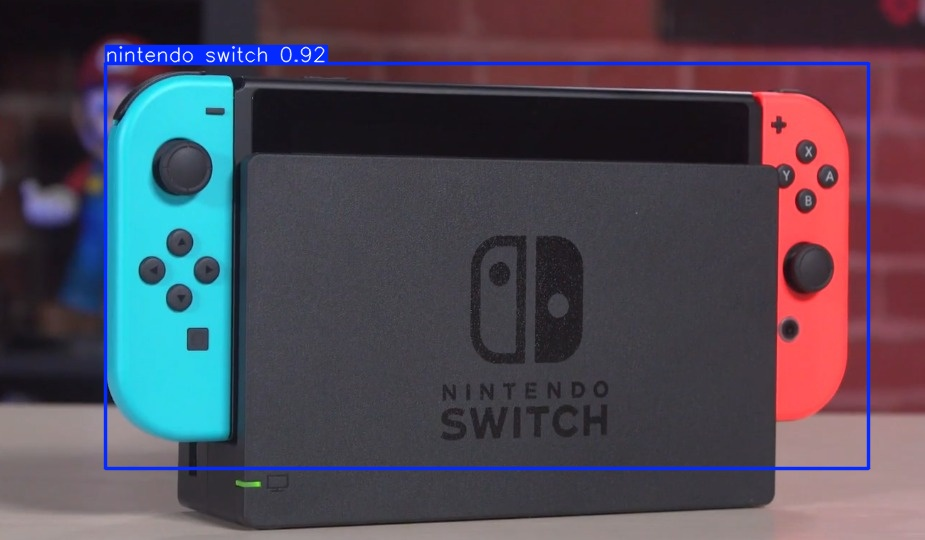

In [7]:
from IPython.display import display, Image
import glob

prediction_files = glob.glob("/content/runs/detect/predict*/*")

display(Image(filename=prediction_files[-1]))

## Install and Create Flask Application


In [8]:
!pip install flask

In [9]:
os.makedirs("templates", exist_ok=True)
os.makedirs("static/uploads", exist_ok=True)
os.makedirs("static/results", exist_ok=True)

In [10]:
import os
import uuid
import cv2

from flask import Flask, render_template, request
from ultralytics import YOLO
from werkzeug.utils import secure_filename

app = Flask(__name__)

UPLOAD_FOLDER = "static/uploads"
RESULT_FOLDER = "static/results"
ALLOWED_EXTENSIONS = {"png", "jpg", "jpeg"}

os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

MODEL_PATH = "/content/drive/MyDrive/Object_Detection_Deployment/best.pt"
model = YOLO(MODEL_PATH)

In [11]:
%%writefile app.py

import os
import uuid

from flask import Flask, render_template, request
from ultralytics import YOLO
from werkzeug.utils import secure_filename

app = Flask(__name__)

UPLOAD_FOLDER = "static/uploads"
RESULT_FOLDER = "static/results"
ALLOWED_EXTENSIONS = {"png", "jpg", "jpeg"}

os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

MODEL_PATH = "/content/drive/MyDrive/Object_Detection_Deployment/best.pt"
model = YOLO(MODEL_PATH)


def allowed_file(filename):
    return (
        "." in filename
        and filename.rsplit(".", 1)[1].lower() in ALLOWED_EXTENSIONS
    )


@app.route("/", methods=["GET", "POST"])
def index():
    result_image = None
    error = None

    if request.method == "POST":
        if "image" not in request.files:
            error = "No image was uploaded."
            return render_template(
                "index.html",
                result_image=result_image,
                error=error
            )

        file = request.files["image"]

        if file.filename == "":
            error = "Please choose an image."
            return render_template(
                "index.html",
                result_image=result_image,
                error=error
            )

        if not allowed_file(file.filename):
            error = "Only PNG, JPG, and JPEG files are allowed."
            return render_template(
                "index.html",
                result_image=result_image,
                error=error
            )

        original_filename = secure_filename(file.filename)
        unique_name = f"{uuid.uuid4().hex}_{original_filename}"
        upload_path = os.path.join(UPLOAD_FOLDER, unique_name)

        file.save(upload_path)

        results = model.predict(
            source=upload_path,
            conf=0.25
        )

        plotted_image = results[0].plot()

        result_filename = f"result_{unique_name}"
        result_path = os.path.join(RESULT_FOLDER, result_filename)

        import cv2
        cv2.imwrite(result_path, plotted_image)

        result_image = result_filename

    return render_template(
        "index.html",
        result_image=result_image,
        error=error
    )


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)

Writing app.py


In [12]:
# create HTML
%%writefile templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Gaming Device Detector</title>

    <style>
        body {
            font-family: Arial, sans-serif;
            background-color: #f4f4f4;
            text-align: center;
            padding: 40px;
        }

        .container {
            max-width: 750px;
            margin: auto;
            background: white;
            padding: 30px;
            border-radius: 12px;
            box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);
        }

        input[type="file"] {
            margin: 20px 0;
        }

        button {
            background-color: #222;
            color: white;
            border: none;
            padding: 12px 24px;
            border-radius: 6px;
            cursor: pointer;
        }

        button:hover {
            background-color: #444;
        }

        img {
            margin-top: 25px;
            max-width: 100%;
            border-radius: 8px;
        }

        .error {
            color: red;
            margin-top: 15px;
        }
    </style>
</head>

<body>
    <div class="container">
        <h1>Nintendo Switch vs Steam Deck Detector</h1>

        <p>Upload an image and the YOLO model will detect the device.</p>

        <form method="POST" enctype="multipart/form-data">
            <input
                type="file"
                name="image"
                accept=".png,.jpg,.jpeg"
                required
            >

            <br>

            <button type="submit">Run Detection</button>
        </form>

        {% if error %}
            <p class="error">{{ error }}</p>
        {% endif %}

        {% if result_image %}
            <h2>Detection Result</h2>

            <img
                src="{{ url_for(
                    'static',
                    filename='results/' + result_image
                ) }}"
                alt="Detection result"
            >
        {% endif %}
    </div>
</body>
</html>

Writing templates/index.html


In [13]:
!find . -maxdepth 3 -type f

./.config/gce
./.config/active_config
./.config/.last_survey_prompt.yaml
./.config/.last_opt_in_prompt.yaml
./.config/.last_update_check.json
./.config/config_sentinel
./.config/configurations/config_default
./.config/default_configs.db
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./app.py
./drive/MyDrive/Recap.gdoc
./drive/MyDrive/Motivation LetterDear Members of the Selection Committee,  I am writing to express my strong interest in the PhD position in~udies. I look forward to the opportunity to discuss my qualifications and motivation further.  Yours sincerely,  [Your Name].gdoc
./drive/MyDrive/Untitled document (3).gdoc
./drive/MyDrive/Cover Letter KTH.gdoc
./drive/MyDrive/Abstract of Published Thesis:.gdoc
./drive/MyDrive/Cover Letter Linnaeus.gdoc
./drive/MyDrive/Cover Letter Uppsala.gdoc
./drive/MyDrive/Cover Letter TUOM.gdoc
./drive/MyDrive/Stroke risk prediction using deep learning .gdoc
./drive/MyDrive/Abuhamra_Cover_Letter.gdoc
./drive/MyDrive/Abu

In [14]:
!head -20 app.py


import os
import uuid

from flask import Flask, render_template, request
from ultralytics import YOLO
from werkzeug.utils import secure_filename

app = Flask(__name__)

UPLOAD_FOLDER = "static/uploads"
RESULT_FOLDER = "static/results"
ALLOWED_EXTENSIONS = {"png", "jpg", "jpeg"}

os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

MODEL_PATH = "/content/drive/MyDrive/Object_Detection_Deployment/best.pt"
model = YOLO(MODEL_PATH)



In [15]:
!pip install pyngrok

In [16]:
from pyngrok import ngrok

ngrok.set_auth_token("3GdvCbutYdGWSB74N2idBnjAgpg_5mC2DcXzpURYzw6fVHUiJ")

In [17]:
ngrok.kill()
!pkill -f app.py

In [18]:
import subprocess
import time
from pyngrok import ngrok

log_file = open("flask.log", "w")

flask_process = subprocess.Popen(
    ["python", "-u", "app.py"],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(5)

public_url = ngrok.connect(5000)

print("Open this link:")
print(public_url.public_url)

Open this link:
https://till-trapped-moonlight.ngrok-free.dev


In [19]:
!cp "/content/drive/MyDrive/Object_Detection_Deployment/best.pt" "/content/best.pt"

In [20]:
import os
print(os.path.exists("/content/best.pt"))

True


# Dockerization

In [21]:
%%writefile requirements.txt
Flask
gunicorn
ultralytics
opencv-python-headless
Pillow

Writing requirements.txt


In [22]:
# Create Docker file
%%writefile Dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

RUN mkdir -p static/uploads static/results

EXPOSE 5000

CMD ["gunicorn", "--bind", "0.0.0.0:5000", "--timeout", "120", "app:app"]

Writing Dockerfile


In [23]:
!find /content -maxdepth 3 -type f | sort

/content/app.py
/content/best.pt
/content/.config/active_config
/content/.config/config_sentinel
/content/.config/configurations/config_default
/content/.config/default_configs.db
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_opt_in_prompt.yaml
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/Dockerfile
/content/drive/MyDrive/Abstract of Published Thesis:.gdoc
/content/drive/MyDrive/Abuhamra_cover_letter_Bremen.gdoc
/content/drive/MyDrive/Abuhamra_cover_letter_Data-driven Materials Modeling.gdoc
/content/drive/MyDrive/Abuhamra_Cover_Letter.gdoc
/content/drive/MyDrive/Abuhamra_cover_letter_TU_Delft.gdoc
/content/drive/MyDrive/Abuhamra_cover_letter_TUMAI.gdoc
/content/drive/MyDrive/Abuhamra_Cover_Letter_TUM.gdoc
/content/drive/MyDrive/Abuhamra_cover_letter_UOH_CS.gdoc
/content/drive/MyDrive/CL.gdoc
/content/drive/MyDrive/Copy of Cover Letter Electrical Systems Planning

In [24]:
import shutil
import os

project_drive_path = "/content/drive/MyDrive/Object_Detection_Deployment/flask_project"

os.makedirs(project_drive_path, exist_ok=True)

shutil.copy("/content/app.py", project_drive_path)
shutil.copy("/content/best.pt", project_drive_path)
shutil.copy("/content/requirements.txt", project_drive_path)
shutil.copy("/content/Dockerfile", project_drive_path)

shutil.copytree(
    "/content/templates",
    os.path.join(project_drive_path, "templates"),
    dirs_exist_ok=True
)

shutil.copytree(
    "/content/static",
    os.path.join(project_drive_path, "static"),
    dirs_exist_ok=True
)

print("Project saved to Google Drive.")

Project saved to Google Drive.
